## Line plot

1. color palette for AR5 & AR6, from pyam package
2. example line plot

In [6]:
# import necessary libraries
import pandas as pd
import pyam
import numpy as np
import matplotlib.pyplot as plt

### 1.color palette for AR5 & AR6, from pyam package

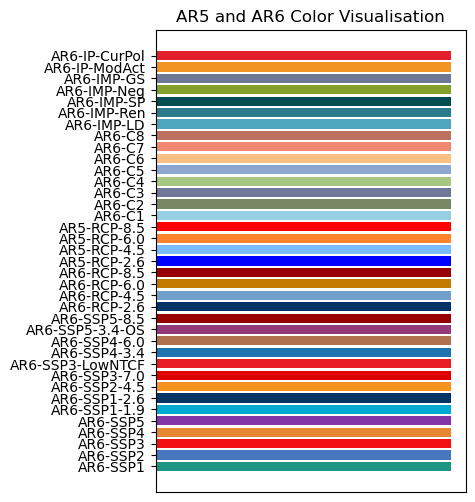

In [7]:
# To show the AR5 and AR6 color palette inside the pyam package
colors = pyam.plotting.PYAM_COLORS

plot_names = list(colors.keys())
plot_colors = list(colors.values())

plt.figure(figsize=(4,6))
plt.barh(plot_names, [1]*len(plot_names), color=plot_colors)
plt.gca().set_xticks([])
plt.gca().set_yticks(range(len(plot_names)))
plt.gca().set_yticklabels(plot_names)
plt.title("AR5 and AR6 Color Visualisation")
plt.show()

In [8]:
# Show the color names and their corresponding hex codes in a DataFrame
pd.DataFrame({"name":plot_names, "color": plot_colors})

,name,color
0,AR6-SSP1,#1e9583
1,AR6-SSP2,#4576be
2,AR6-SSP3,#f11111
3,AR6-SSP4,#e78731
4,AR6-SSP5,#8036a7
5,AR6-SSP1-1.9,#00a9cf
6,AR6-SSP1-2.6,#003466
7,AR6-SSP2-4.5,#f69320
8,AR6-SSP3-7.0,#df0000
9,AR6-SSP3-LowNTCF,#e61d25


### 2. example line plot

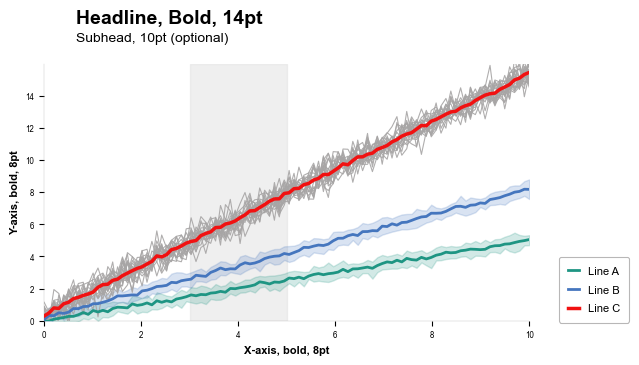

In [9]:
# Simulate data
np.random.seed(42)
x = np.linspace(0, 10, 100)
num_lines = 3
samples = []

slopes = [0.5, 0.8, 1.5]

for i in range(num_lines):
    base_line = slopes[i] * x + 0.2 * i
    data = base_line[:, None] + 0.3 * np.random.randn(100, 20)
    samples.append(data)

colors = ['#1e9583', '#4576be', '#f11111']
labels = ['Line A', 'Line B', 'Line C']

fig, ax = plt.subplots(figsize=(6.5, 3.65)) # 165mm x 92.5mm in inches


# Calculate global limits
x_min = np.min(x)
x_max = np.max(x)

all_y = np.concatenate(samples, axis=1)
y_min = np.min(all_y)
y_max = np.max(all_y)

ax.set_xlim(0, x_max) # box start at 0 and end exactly at data
ax.set_ylim(0, y_max) # box start at 0 and end exactly at data

# Calculate left position of the plot area
ax_pos = ax.get_position()
ax_left = ax_pos.x0

# Grey highlight vertical band between x=3 and x=5
ax.axvspan(3, 5, color='#d9d9d9', alpha=0.4, zorder=0)


# Plot Lines A & B
for i in range(2):
    y_mean = np.mean(samples[i], axis=1)
    y_5th = np.percentile(samples[i], 5, axis=1)
    y_95th = np.percentile(samples[i], 95, axis=1)

    ax.fill_between(x, y_5th, y_95th,
                    color=colors[i], alpha=0.2, zorder=1)

    ax.plot(x, y_mean,
            color=colors[i],
            linewidth=2,
            label=labels[i],
            zorder=3)

  
# 20 thin grey scenario lines around RED line
red_mean = np.mean(samples[2], axis=1)

for i in range(20):
    scenario = red_mean + 0.5 * np.random.randn(len(x))
    ax.plot(x, scenario,
            color='#a7a5a5',
            linewidth=0.8,
            alpha=0.9,
            zorder=2)

  
# Red mean line ON TOP of all scenario lines
ax.plot(x, red_mean,
        color=colors[2],
        linewidth=2.5,
        label=labels[2],
        zorder=5)

  
# Axis styling
grey_axis = '#a7a5a5'

# Bottom & left in grey
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color(grey_axis)
    ax.spines[spine].set_linewidth(0.2)

# for spine in ['top', 'right']: # top and right in black
#     ax.spines[spine].set_visible(True)
#     ax.spines[spine].set_color(black_axis)
#     ax.spines[spine].set_linewidth(1)

for spine in ['top', 'right']: # remove top and right spines
    ax.spines[spine].set_visible(False)


# Ticks, in black, 8pt
ax.tick_params(axis='x', colors='#000000', labelsize=7)
ax.tick_params(axis='y', colors='#000000', labelsize=7)

for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontname('Arial Narrow')

# Axis labels
label_font = {
    'family': 'Arial',
    'weight': 'bold',
    'size': 8
}

ax.set_xlabel('X-axis, bold, 8pt', fontdict=label_font)
ax.set_ylabel('Y-axis, bold, 8pt', fontdict=label_font)

  
# Legend (grey box + equal spacing)
legend = ax.legend(
    prop={'family': 'Arial', 'size': 8},
    loc='center left',
    bbox_to_anchor=(1.05, 0.12),
    frameon=True,
    borderpad=0.8,
    labelspacing=0.8,
    handlelength=1,
    handletextpad=0.8
)

legend.get_frame().set_linewidth(0.8)
legend.get_frame().set_edgecolor('#a7a5a5')


# Headline
fig.text(
    x=ax_left,
    y=0.95,
    s="Headline, Bold, 14pt",
    fontsize=14,
    fontweight='bold',
    fontname='Arial',
    
)

# Subhead (optional)
fig.text(
    x=ax_left,
    y=0.90,
    s="Subhead, 10pt (optional)",
    fontsize=10,
    fontname='Arial',
    ha='left'
)


plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.savefig("./fig_svg/fig_line.svg")
plt.show()
plt.close()
